# XGBoost Model Building

**Project:** N₂O Emissions in Sub-Saharan Africa  
**Notebook objective:** Development, validation, tuning, diagnosis, and export of an XGBoost regression model for predicting N₂O flux.

This notebook documents the transition from exploratory data analysis to supervised model building. The modeling setup is based on the main observations from the EDA:

- The target variable is continuous, strongly right-skewed, and affected by extreme values.
- The dataset contains repeated observations that are grouped by `Event`.
- `Event` is treated as a grouping variable for validation and is excluded from the predictor set to reduce data leakage.
- Spatial coordinates, land-use information, meteorological variables, soil variables, fertilizer-related variables, and engineered temporal features are used as predictors.
- Model performance is evaluated on previously unseen events using a grouped train-test split.

# Table of Contents

1. Modeling Strategy
2. Imports and Configuration
3. Data Loading
4. Target and Feature Configuration
5. Feature Engineering
6. Train-Test Split by Event
7. Preprocessing Pipeline
8. Baseline Model
9. Initial XGBoost Model
10. Hyperparameter Tuning with Grouped Cross-Validation
11. Final Model Evaluation
12. Error Analysis
13. Feature Importance
14. Diagnostic Plots
15. Save Model Artifacts
16. Optional Final Refit on All Data
17. Summary and Next Steps

## 1. Modeling Strategy

The objective of the modeling step is to estimate the modeled N₂O flux from environmental, spatial, land-use, soil, and fertilizer-related predictors.

The modeling design follows four main decisions:

1. **Grouped validation:** Observations from the same `Event` are likely not independent. A random row-level split could therefore lead to overly optimistic performance estimates. For this reason, `Event` is used as the grouping variable for the holdout split and for cross-validation.
2. **Target transformation:** The EDA showed that N₂O flux is skewed and includes negative values. A shifted `log1p` transformation is tested for the tuned model. The shift is derived only from the training target to prevent leakage from the test set.
3. **Categorical encoding:** `Land use` is encoded with one-hot encoding. `Event` is not used as a direct model feature, because it mainly identifies measurement groups and could cause leakage.
4. **Robust evaluation:** Model quality is assessed using MAE, RMSE, R², median absolute error, bias, and residual summaries. MAE is especially relevant because the target contains extreme emission values.

## 2. Imports and Configuration

This section defines the required libraries, global plotting settings, warning behavior, and reproducibility settings used throughout the modeling workflow.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost is not installed. Install it with: pip install xgboost"
    ) from exc

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_ITER_SEARCH = 30
N_JOBS = -1


## 3. Data Loading

The dataset is loaded from a set of possible project paths. This makes the notebook executable from different working directories, such as the repository root, the `notebooks/` folder, or a temporary execution environment.

In [2]:
def find_existing_path(
    candidate_paths: Sequence[Path],
    verbose: bool = False,
) -> Path:
    """
    Return the first existing path from a sequence of candidate paths.

    Parameters
    ----------
    candidate_paths : Sequence[Path]
        Candidate file paths that should be checked in order.
    verbose : bool, default=False
        If True, print every checked path and the final selected path.

    Returns
    -------
    Path
        The first path that exists.

    Raises
    ------
    FileNotFoundError
        If none of the candidate paths exists.
    TypeError
        If candidate_paths is not an iterable of Path-like objects.
    """
    if not isinstance(candidate_paths, Iterable):
        raise TypeError("candidate_paths must be an iterable of Path objects.")

    checked_paths: List[Path] = []

    for candidate_path in candidate_paths:
        path = Path(candidate_path)
        checked_paths.append(path)

        if verbose:
            print(f"Checking path: {path.resolve()}")

        if path.exists():
            if verbose:
                print(f"Selected path: {path.resolve()}")
            return path

    checked_text = "\n".join(str(path) for path in checked_paths)
    raise FileNotFoundError(
        "None of the candidate paths exists. Checked paths:\n" + checked_text
    )


def load_dataset(
    csv_path: Path,
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Load a CSV dataset into a pandas DataFrame.

    Parameters
    ----------
    csv_path : Path
        Path to the CSV file.
    verbose : bool, default=False
        If True, print information about the loaded dataset.

    Returns
    -------
    pd.DataFrame
        Loaded dataset.

    Raises
    ------
    FileNotFoundError
        If the CSV file does not exist.
    ValueError
        If the loaded dataset is empty.
    """
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    dataframe = pd.read_csv(csv_path)

    if dataframe.empty:
        raise ValueError(f"Loaded dataset is empty: {csv_path}")

    if verbose:
        print(f"Loaded dataset from: {csv_path.resolve()}")
        print(f"Shape: {dataframe.shape[0]:,} rows x {dataframe.shape[1]:,} columns")

    return dataframe


project_root = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

DATA_PATH = find_existing_path(
    [
        project_root / "data" / "interim" / "n2o_ssa_landuse_aligned_combined.csv",
        project_root / "data" / "processed" / "n2o_ssa_landuse_aligned_combined.csv",
        Path("../data/interim/n2o_ssa_landuse_aligned_combined.csv"),
        Path("../data/processed/n2o_ssa_landuse_aligned_combined.csv"),
        Path("/mnt/data/n2o_ssa_landuse_aligned_combined.csv"),
    ],
    verbose=True,
)

df_raw = load_dataset(DATA_PATH, verbose=True)
df_raw.head()


Checking path: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\data\interim\n2o_ssa_landuse_aligned_combined.csv
Selected path: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\data\interim\n2o_ssa_landuse_aligned_combined.csv
Loaded dataset from: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\data\interim\n2o_ssa_landuse_aligned_combined.csv
Shape: 5,280 rows x 27 columns


,Event,Latitude,Longitude,Date/Time,Land use,Fert N [kg/ha] (Recorded at time of application),TTT day m [°C] (ERA5 reanalyses),TxTxTx day max [°C] (ERA5 reanalyses),TnTnTn day min [°C] (ERA5 reanalyses),Precip day total [mm/day] (ERA5 reanalyses),...,VPD day m [kPa] (ERA5 reanalyses),PPPP day m [hPa] (ERA5 reanalyses),SWD day m [W/m**2] (ERA5 reanalyses),PPFD day m [µmol/m**2/s] (ERA5 reanalyses),Duration [days] (Since last precipitation even...),Duration [days] (Since last fertiliser applica...),Fert N dec adj exp [kg/ha] (Exponential decay model (k=0.05)),Transformation S (Modeled),Transformation C (Modeled),"N2O flux [µg/m**2/h] (From soil surface, Modeled)"
0,17AG-KILO-FLM,-3.1651,37.2354,2011-03-10,Forest,0,18.030489,23.117343,12.340325,0.067297,...,0.822001,819.566199,50.327010,101.660557,0,0,0.0,0.985770,-0.168101,0.490975
1,17AG-KILO-FLM,-3.1651,37.2354,2011-03-17,Forest,0,17.544443,20.264432,15.170010,8.913426,...,0.262965,818.716753,30.537043,61.684828,0,0,0.0,0.959059,-0.283206,0.000000
2,17AG-KILO-FLM,-3.1651,37.2354,2011-05-07,Forest,0,17.823329,20.757046,15.629188,0.358296,...,0.318645,821.894519,34.651581,69.996192,0,0,0.0,0.394356,-0.918958,-0.457550
3,17AG-KILO-COF,-3.2454,37.3195,2011-05-11,Forest,0,16.740588,19.703080,15.208345,1.130527,...,0.135640,835.511386,27.307722,55.161598,0,0,0.0,0.331418,-0.943484,59.965733
4,17AG-KILO-FOC,-3.1424,37.2423,2011-05-13,Forest,0,16.970899,20.616940,14.695255,0.460711,...,0.245536,816.466490,40.836629,82.489988,0,0,0.0,0.299363,-0.954139,47.169444


## 4. Target and Feature Configuration

This section defines the target variable, grouping column, date column, and required columns. The configuration is kept explicit so that later preprocessing and validation steps remain reproducible and easy to inspect.

In [3]:
TARGET_COLUMN = "N2O flux [µg/m**2/h] (From soil surface, Modeled)"
GROUP_COLUMN = "Event"
DATE_COLUMN = "Date/Time"
LAND_USE_COLUMN = "Land use"

REQUIRED_COLUMNS = [
    TARGET_COLUMN,
    GROUP_COLUMN,
    DATE_COLUMN,
    LAND_USE_COLUMN,
    "Latitude",
    "Longitude",
]


def validate_required_columns(
    dataframe: pd.DataFrame,
    required_columns: Sequence[str],
    verbose: bool = False,
) -> None:
    """
    Validate that all required columns are present in a DataFrame.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Dataset to validate.
    required_columns : Sequence[str]
        Column names that must exist in the dataset.
    verbose : bool, default=False
        If True, print validation details.

    Returns
    -------
    None

    Raises
    ------
    TypeError
        If dataframe is not a pandas DataFrame.
    ValueError
        If at least one required column is missing.
    """
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError("dataframe must be a pandas DataFrame.")

    missing_columns = [column for column in required_columns if column not in dataframe.columns]

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    if verbose:
        print("All required columns are available.")


validate_required_columns(df_raw, REQUIRED_COLUMNS, verbose=True)

print(f"Target column: {TARGET_COLUMN}")
print(f"Group column : {GROUP_COLUMN}")
print(f"Date column  : {DATE_COLUMN}")
print(f"Land use     : {LAND_USE_COLUMN}")


All required columns are available.
Target column: N2O flux [µg/m**2/h] (From soil surface, Modeled)
Group column : Event
Date column  : Date/Time
Land use     : Land use


In [4]:
# Quick target overview before modeling.
df_raw[TARGET_COLUMN].describe()


count    5280.000000
mean       12.095709
std        20.839097
min       -21.149615
25%         1.896372
50%         5.142646
75%        13.045997
max       242.346036
Name: N2O flux [µg/m**2/h] (From soil surface, Modeled), dtype: float64

## 5. Feature Engineering

The feature engineering step converts the date column and creates additional temporal, cyclic, and interaction-based predictors. These features are derived from the EDA results and from process-related assumptions about N₂O emissions.

The raw date column is not used directly as a model feature. Instead, structured temporal information such as year, month, seasonality, and cyclic encodings is extracted.

In [5]:
def add_model_features(
    dataframe: pd.DataFrame,
    date_column: str,
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Add modeling features derived from date, weather, soil, and fertilizer variables.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Input dataset.
    date_column : str
        Name of the date column.
    verbose : bool, default=False
        If True, print information about generated features.

    Returns
    -------
    pd.DataFrame
        Dataset with additional engineered features.

    Raises
    ------
    TypeError
        If dataframe is not a pandas DataFrame.
    ValueError
        If date_column is missing.
    """
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError("dataframe must be a pandas DataFrame.")

    if date_column not in dataframe.columns:
        raise ValueError(f"date_column is missing from dataframe: {date_column}")

    df_features = dataframe.copy()
    created_features: List[str] = []

    # Convert the date column to pandas datetime. Invalid dates become NaT.
    df_features[date_column] = pd.to_datetime(df_features[date_column], errors="coerce")

    # Basic temporal features.
    df_features["year"] = df_features[date_column].dt.year
    df_features["month"] = df_features[date_column].dt.month
    df_features["day_of_year"] = df_features[date_column].dt.dayofyear
    df_features["week_of_year"] = df_features[date_column].dt.isocalendar().week.astype("float")
    created_features.extend(["year", "month", "day_of_year", "week_of_year"])

    # Cyclic temporal encoding. This helps tree models, but is especially useful
    # for representing calendar periodicity without artificial month boundaries.
    df_features["month_sin"] = np.sin(2 * np.pi * df_features["month"] / 12)
    df_features["month_cos"] = np.cos(2 * np.pi * df_features["month"] / 12)
    df_features["day_of_year_sin"] = np.sin(2 * np.pi * df_features["day_of_year"] / 365.25)
    df_features["day_of_year_cos"] = np.cos(2 * np.pi * df_features["day_of_year"] / 365.25)
    created_features.extend(["month_sin", "month_cos", "day_of_year_sin", "day_of_year_cos"])

    # Seasonal feature for interpretable categorical seasonality.
    month_to_season = {
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON",
    }
    df_features["season"] = df_features["month"].map(month_to_season)
    created_features.append("season")

    # Temperature range can represent diurnal temperature variability.
    max_temp_col = "TxTxTx day max [°C] (ERA5 reanalyses)"
    min_temp_col = "TnTnTn day min [°C] (ERA5 reanalyses)"
    if max_temp_col in df_features.columns and min_temp_col in df_features.columns:
        df_features["air_temp_range"] = df_features[max_temp_col] - df_features[min_temp_col]
        created_features.append("air_temp_range")

    # Fertilizer intensity adjusted by time since fertilization.
    fert_col = "Fert N [kg/ha] (Recorded at time of application)"
    fert_duration_col = "Duration [days] (Since last fertiliser applica...)"
    if fert_col in df_features.columns and fert_duration_col in df_features.columns:
        df_features["fert_n_per_day_since_application"] = (
            df_features[fert_col] / (1 + df_features[fert_duration_col].clip(lower=0))
        )
        created_features.append("fert_n_per_day_since_application")

    # Precipitation recency proxy. Shorter time since precipitation can indicate wetter conditions.
    precip_duration_col = "Duration [days] (Since last precipitation even...)"
    if precip_duration_col in df_features.columns:
        df_features["precip_recency_decay"] = np.exp(-0.05 * df_features[precip_duration_col].clip(lower=0))
        created_features.append("precip_recency_decay")

    # Interaction terms motivated by N2O process understanding.
    mean_temp_col = "TTT day m [°C] (ERA5 reanalyses)"
    soil_moisture_col = "Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)"
    if mean_temp_col in df_features.columns and soil_moisture_col in df_features.columns:
        df_features["air_temp_x_topsoil_moisture"] = (
            df_features[mean_temp_col] * df_features[soil_moisture_col]
        )
        created_features.append("air_temp_x_topsoil_moisture")

    if fert_col in df_features.columns and soil_moisture_col in df_features.columns:
        df_features["fert_n_x_topsoil_moisture"] = (
            df_features[fert_col] * df_features[soil_moisture_col]
        )
        created_features.append("fert_n_x_topsoil_moisture")

    if fert_col in df_features.columns and mean_temp_col in df_features.columns:
        df_features["fert_n_x_air_temp"] = df_features[fert_col] * df_features[mean_temp_col]
        created_features.append("fert_n_x_air_temp")

    if verbose:
        print(f"Created {len(created_features)} engineered features:")
        for feature in created_features:
            print(f"- {feature}")

    return df_features


df_model = add_model_features(df_raw, date_column=DATE_COLUMN, verbose=True)
df_model.head()


Created 15 engineered features:
- year
- month
- day_of_year
- week_of_year
- month_sin
- month_cos
- day_of_year_sin
- day_of_year_cos
- season
- air_temp_range
- fert_n_per_day_since_application
- precip_recency_decay
- air_temp_x_topsoil_moisture
- fert_n_x_topsoil_moisture
- fert_n_x_air_temp


,Event,Latitude,Longitude,Date/Time,Land use,Fert N [kg/ha] (Recorded at time of application),TTT day m [°C] (ERA5 reanalyses),TxTxTx day max [°C] (ERA5 reanalyses),TnTnTn day min [°C] (ERA5 reanalyses),Precip day total [mm/day] (ERA5 reanalyses),...,month_cos,day_of_year_sin,day_of_year_cos,season,air_temp_range,fert_n_per_day_since_application,precip_recency_decay,air_temp_x_topsoil_moisture,fert_n_x_topsoil_moisture,fert_n_x_air_temp
0,17AG-KILO-FLM,-3.1651,37.2354,2011-03-10,Forest,0,18.030489,23.117343,12.340325,0.067297,...,6.123234e-17,0.927238,0.374474,MAM,10.777018,0.0,1.0,5.381694,0.0,0.0
1,17AG-KILO-FLM,-3.1651,37.2354,2011-03-17,Forest,0,17.544443,20.264432,15.170010,8.913426,...,6.123234e-17,0.965507,0.260376,MAM,5.094422,0.0,1.0,6.845310,0.0,0.0
2,17AG-KILO-FLM,-3.1651,37.2354,2011-05-07,Forest,0,17.823329,20.757046,15.629188,0.358296,...,-8.660254e-01,0.817401,-0.576069,MAM,5.127858,0.0,1.0,5.868944,0.0,0.0
3,17AG-KILO-COF,-3.2454,37.3195,2011-05-11,Forest,0,16.740588,19.703080,15.208345,1.130527,...,-8.660254e-01,0.775859,-0.630907,MAM,4.494736,0.0,1.0,6.302345,0.0,0.0
4,17AG-KILO-FOC,-3.1424,37.2423,2011-05-13,Forest,0,16.970899,20.616940,14.695255,0.460711,...,-8.660254e-01,0.753698,-0.657221,MAM,5.921685,0.0,1.0,6.308256,0.0,0.0


In [6]:
def prepare_model_matrix(
    dataframe: pd.DataFrame,
    target_column: str,
    group_column: str,
    date_column: str,
    verbose: bool = False,
) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """
    Prepare feature matrix, target vector, and group vector for modeling.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Input dataset after feature engineering.
    target_column : str
        Name of the target variable.
    group_column : str
        Name of the grouping variable used for grouped splitting.
    date_column : str
        Name of the raw date column to exclude from features.
    verbose : bool, default=False
        If True, print feature matrix information.

    Returns
    -------
    Tuple[pd.DataFrame, pd.Series, pd.Series]
        X, y, and groups.

    Raises
    ------
    ValueError
        If required columns are missing or if the target contains missing values.
    """
    required = [target_column, group_column, date_column]
    missing = [column for column in required if column not in dataframe.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if dataframe[target_column].isna().any():
        raise ValueError("Target column contains missing values. Handle them before modeling.")

    # Event is used for validation groups and intentionally excluded from predictors.
    # The raw date column is excluded because engineered temporal features already represent date information.
    drop_columns = [target_column, group_column, date_column]

    X = dataframe.drop(columns=drop_columns)
    y = dataframe[target_column].copy()
    groups = dataframe[group_column].copy()

    if verbose:
        print(f"Feature matrix shape: {X.shape}")
        print(f"Target shape        : {y.shape}")
        print(f"Number of groups    : {groups.nunique()}")
        print(f"Excluded columns    : {drop_columns}")

    return X, y, groups


X, y, groups = prepare_model_matrix(
    df_model,
    target_column=TARGET_COLUMN,
    group_column=GROUP_COLUMN,
    date_column=DATE_COLUMN,
    verbose=True,
)

X.head()


Feature matrix shape: (5280, 39)
Target shape        : (5280,)
Number of groups    : 33
Excluded columns    : ['N2O flux [µg/m**2/h] (From soil surface, Modeled)', 'Event', 'Date/Time']


,Latitude,Longitude,Land use,Fert N [kg/ha] (Recorded at time of application),TTT day m [°C] (ERA5 reanalyses),TxTxTx day max [°C] (ERA5 reanalyses),TnTnTn day min [°C] (ERA5 reanalyses),Precip day total [mm/day] (ERA5 reanalyses),"Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)",Soil moisture [m**3/m**3] (ERA5 reanalyses),...,month_cos,day_of_year_sin,day_of_year_cos,season,air_temp_range,fert_n_per_day_since_application,precip_recency_decay,air_temp_x_topsoil_moisture,fert_n_x_topsoil_moisture,fert_n_x_air_temp
0,-3.1651,37.2354,Forest,0,18.030489,23.117343,12.340325,0.067297,0.298477,0.319371,...,6.123234e-17,0.927238,0.374474,MAM,10.777018,0.0,1.0,5.381694,0.0,0.0
1,-3.1651,37.2354,Forest,0,17.544443,20.264432,15.170010,8.913426,0.390170,0.365656,...,6.123234e-17,0.965507,0.260376,MAM,5.094422,0.0,1.0,6.845310,0.0,0.0
2,-3.1651,37.2354,Forest,0,17.823329,20.757046,15.629188,0.358296,0.329284,0.334593,...,-8.660254e-01,0.817401,-0.576069,MAM,5.127858,0.0,1.0,5.868944,0.0,0.0
3,-3.2454,37.3195,Forest,0,16.740588,19.703080,15.208345,1.130527,0.376471,0.336664,...,-8.660254e-01,0.775859,-0.630907,MAM,4.494736,0.0,1.0,6.302345,0.0,0.0
4,-3.1424,37.2423,Forest,0,16.970899,20.616940,14.695255,0.460711,0.371710,0.364974,...,-8.660254e-01,0.753698,-0.657221,MAM,5.921685,0.0,1.0,6.308256,0.0,0.0


## 6. Train-Test Split by Event

The holdout split is performed at event level. Complete events are assigned either to the training set or to the test set. This creates a stricter validation scenario than a random row-level split and better reflects the question of how well the model generalizes to unseen measurement events.

In [7]:
def split_by_group(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    test_size: float = 0.2,
    random_state: int = 42,
    verbose: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series, pd.Series]:
    """
    Split features and target into train and test sets using group-aware splitting.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Target vector.
    groups : pd.Series
        Group labels. Samples with the same group are kept in the same split.
    test_size : float, default=0.2
        Fraction of groups assigned to the test set.
    random_state : int, default=42
        Random seed for reproducibility.
    verbose : bool, default=False
        If True, print split diagnostics.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series, pd.Series]
        X_train, X_test, y_train, y_test, groups_train, groups_test.

    Raises
    ------
    ValueError
        If inputs have inconsistent lengths or too few unique groups.
    """
    if not (len(X) == len(y) == len(groups)):
        raise ValueError("X, y, and groups must have the same length.")

    if groups.nunique() < 3:
        raise ValueError("At least three unique groups are required for grouped splitting.")

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state,
    )

    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()
    groups_train = groups.iloc[train_idx].copy()
    groups_test = groups.iloc[test_idx].copy()

    overlap = set(groups_train.unique()).intersection(set(groups_test.unique()))
    if overlap:
        raise ValueError(f"Group leakage detected. Overlapping groups: {overlap}")

    if verbose:
        print(f"Train rows       : {len(X_train):,}")
        print(f"Test rows        : {len(X_test):,}")
        print(f"Train groups     : {groups_train.nunique():,}")
        print(f"Test groups      : {groups_test.nunique():,}")
        print(f"Group overlap    : {len(overlap)}")
        print(f"Train target mean: {y_train.mean():.4f}")
        print(f"Test target mean : {y_test.mean():.4f}")

    return X_train, X_test, y_train, y_test, groups_train, groups_test


X_train, X_test, y_train, y_test, groups_train, groups_test = split_by_group(
    X,
    y,
    groups,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    verbose=True,
)


Train rows       : 4,907
Test rows        : 373
Train groups     : 26
Test groups      : 7
Group overlap    : 0
Train target mean: 12.1285
Test target mean : 11.6647


In [8]:
def summarize_split_distribution(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    land_use_column: str,
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Create a compact summary of train-test distribution differences.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features.
    X_test : pd.DataFrame
        Test features.
    y_train : pd.Series
        Training target values.
    y_test : pd.Series
        Test target values.
    land_use_column : str
        Name of the land-use column.
    verbose : bool, default=False
        If True, print summary diagnostics.

    Returns
    -------
    pd.DataFrame
        Summary table with row counts and target statistics by split.

    Raises
    ------
    ValueError
        If the land-use column is missing from one of the feature matrices.
    """
    if land_use_column not in X_train.columns or land_use_column not in X_test.columns:
        raise ValueError(f"Land-use column missing: {land_use_column}")

    train_summary = pd.DataFrame({
        "split": "train",
        "land_use": X_train[land_use_column],
        "target": y_train,
    })
    test_summary = pd.DataFrame({
        "split": "test",
        "land_use": X_test[land_use_column],
        "target": y_test,
    })

    summary = pd.concat([train_summary, test_summary], axis=0)
    result = (
        summary
        .groupby(["split", "land_use"])["target"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
    )

    if verbose:
        print("Created split distribution summary.")

    return result


split_distribution = summarize_split_distribution(
    X_train,
    X_test,
    y_train,
    y_test,
    land_use_column=LAND_USE_COLUMN,
    verbose=True,
)

split_distribution


Created split distribution summary.


,split,land_use,count,mean,median,std,min,max
0,test,Cropland,90,25.060599,9.998872,39.502114,-12.719491,214.808427
1,test,Forest,161,11.983265,7.674300,14.670628,-7.100000,93.700000
2,test,Grassland,122,1.361995,1.038333,3.421183,-9.046667,17.496667
3,train,Cropland,3484,11.544503,5.445589,20.047043,-21.149615,242.346036
4,train,Forest,1320,13.848248,4.258871,22.241465,-11.501391,170.241240
5,train,Grassland,103,9.841595,3.873333,17.348942,-11.130000,118.179897


## 7. Preprocessing Pipeline

The preprocessing pipeline applies consistent transformations to numerical and categorical features. Numerical variables are imputed where necessary, while categorical variables are one-hot encoded.

Feature scaling is not required for XGBoost, because tree-based models are invariant to monotonic transformations of individual feature scales. The pipeline is still useful because it ensures that training, validation, and prediction use identical preprocessing steps.

In [9]:
def make_one_hot_encoder(verbose: bool = False) -> OneHotEncoder:
    """
    Create a OneHotEncoder compatible with multiple scikit-learn versions.

    Parameters
    ----------
    verbose : bool, default=False
        If True, print which encoder argument is used.

    Returns
    -------
    OneHotEncoder
        Configured one-hot encoder.
    """
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        if verbose:
            print("Using OneHotEncoder with sparse_output=False.")
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
        if verbose:
            print("Using OneHotEncoder with sparse=False.")

    return encoder


def get_feature_type_lists(
    X: pd.DataFrame,
    verbose: bool = False,
) -> Tuple[List[str], List[str]]:
    """
    Identify numeric and categorical feature columns.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    verbose : bool, default=False
        If True, print the identified feature types.

    Returns
    -------
    Tuple[List[str], List[str]]
        Numeric feature names and categorical feature names.

    Raises
    ------
    TypeError
        If X is not a pandas DataFrame.
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")

    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

    if verbose:
        print(f"Numeric features    : {len(numeric_features)}")
        print(f"Categorical features: {len(categorical_features)}")
        print("Categorical columns :", categorical_features)

    return numeric_features, categorical_features


def build_preprocessor(
    numeric_features: Sequence[str],
    categorical_features: Sequence[str],
    verbose: bool = False,
) -> ColumnTransformer:
    """
    Build a preprocessing transformer for numerical and categorical features.

    Parameters
    ----------
    numeric_features : Sequence[str]
        Numerical feature names.
    categorical_features : Sequence[str]
        Categorical feature names.
    verbose : bool, default=False
        If True, print preprocessing details.

    Returns
    -------
    ColumnTransformer
        Preprocessing transformer.
    """
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder(verbose=verbose)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, list(numeric_features)),
            ("categorical", categorical_pipeline, list(categorical_features)),
        ],
        remainder="drop",
    )

    if verbose:
        print("Preprocessor created.")

    return preprocessor


numeric_features, categorical_features = get_feature_type_lists(X_train, verbose=True)
preprocessor = build_preprocessor(numeric_features, categorical_features, verbose=True)


Numeric features    : 37
Categorical features: 2
Categorical columns : ['Land use', 'season']
Using OneHotEncoder with sparse_output=False.
Preprocessor created.


## 8. Baseline Model

A baseline model is included as a reference point. It predicts a constant value based on the training target distribution. This makes it possible to judge whether XGBoost learns meaningful structure beyond a simple central tendency of the target.

In [10]:
def regression_metrics(
    y_true: Sequence[float],
    y_pred: Sequence[float],
    prefix: str = "",
    verbose: bool = False,
) -> Dict[str, float]:
    """
    Calculate standard regression metrics.

    Parameters
    ----------
    y_true : Sequence[float]
        True target values.
    y_pred : Sequence[float]
        Predicted target values.
    prefix : str, default=""
        Optional prefix for metric names.
    verbose : bool, default=False
        If True, print calculated metrics.

    Returns
    -------
    Dict[str, float]
        Dictionary containing MAE, RMSE, R2, median absolute error, and bias.

    Raises
    ------
    ValueError
        If y_true and y_pred have different lengths.
    """
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)

    if y_true_array.shape[0] != y_pred_array.shape[0]:
        raise ValueError("y_true and y_pred must have the same length.")

    residuals = y_true_array - y_pred_array

    metrics = {
        f"{prefix}mae": mean_absolute_error(y_true_array, y_pred_array),
        f"{prefix}rmse": float(np.sqrt(mean_squared_error(y_true_array, y_pred_array))),
        f"{prefix}r2": r2_score(y_true_array, y_pred_array),
        f"{prefix}median_ae": median_absolute_error(y_true_array, y_pred_array),
        f"{prefix}bias_mean_residual": float(np.mean(residuals)),
    }

    if verbose:
        for name, value in metrics.items():
            print(f"{name}: {value:.4f}")

    return metrics


def fit_baseline_model(
    y_train: pd.Series,
    y_test: pd.Series,
    strategy: str = "median",
    verbose: bool = False,
) -> Tuple[DummyRegressor, Dict[str, float]]:
    """
    Fit and evaluate a constant baseline regression model.

    Parameters
    ----------
    y_train : pd.Series
        Training target values.
    y_test : pd.Series
        Test target values.
    strategy : str, default="median"
        DummyRegressor strategy.
    verbose : bool, default=False
        If True, print model details and metrics.

    Returns
    -------
    Tuple[DummyRegressor, Dict[str, float]]
        Fitted baseline model and evaluation metrics.
    """
    baseline = DummyRegressor(strategy=strategy)

    # DummyRegressor expects a feature matrix. A zero-column placeholder is enough.
    X_train_dummy = np.zeros((len(y_train), 1))
    X_test_dummy = np.zeros((len(y_test), 1))

    baseline.fit(X_train_dummy, y_train)
    predictions = baseline.predict(X_test_dummy)

    metrics = regression_metrics(y_test, predictions, prefix="baseline_", verbose=verbose)

    return baseline, metrics


baseline_model, baseline_metrics = fit_baseline_model(
    y_train,
    y_test,
    strategy="median",
    verbose=True,
)

pd.DataFrame([baseline_metrics])


baseline_mae: 11.5324
baseline_rmse: 24.2531
baseline_r2: -0.0763
baseline_median_ae: 5.0067
baseline_bias_mean_residual: 6.4582


,baseline_mae,baseline_rmse,baseline_r2,baseline_median_ae,baseline_bias_mean_residual
0,11.532382,24.253118,-0.076319,5.006693,6.458232


## 9. Initial XGBoost Model

The first XGBoost model is trained on the original target scale. This model provides an initial performance estimate and serves as a direct comparison against the baseline before target transformation and hyperparameter tuning.

In [11]:
def build_xgb_pipeline(
    preprocessor: ColumnTransformer,
    model_params: Optional[Dict[str, Any]] = None,
    verbose: bool = False,
) -> Pipeline:
    """
    Build a preprocessing + XGBoost regression pipeline.

    Parameters
    ----------
    preprocessor : ColumnTransformer
        Preprocessing transformer.
    model_params : Optional[Dict[str, Any]], default=None
        XGBRegressor hyperparameters.
    verbose : bool, default=False
        If True, print model parameters.

    Returns
    -------
    Pipeline
        Scikit-learn pipeline with preprocessing and XGBoost model.
    """
    default_params: Dict[str, Any] = {
        "objective": "reg:squarederror",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
        "random_state": RANDOM_STATE,
        "n_jobs": N_JOBS,
    }

    if model_params is not None:
        default_params.update(model_params)

    model = XGBRegressor(**default_params)

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )

    if verbose:
        print("XGBoost pipeline created with parameters:")
        for key, value in default_params.items():
            print(f"- {key}: {value}")

    return pipeline


xgb_initial = build_xgb_pipeline(preprocessor, verbose=True)
xgb_initial.fit(X_train, y_train)

initial_predictions = xgb_initial.predict(X_test)
initial_metrics = regression_metrics(y_test, initial_predictions, prefix="xgb_initial_", verbose=True)

pd.DataFrame([baseline_metrics | initial_metrics])


XGBoost pipeline created with parameters:
- objective: reg:squarederror
- n_estimators: 500
- learning_rate: 0.05
- max_depth: 4
- subsample: 0.8
- colsample_bytree: 0.8
- reg_alpha: 0.0
- reg_lambda: 1.0
- random_state: 42
- n_jobs: -1


xgb_initial_mae: 11.8490
xgb_initial_rmse: 22.6899
xgb_initial_r2: 0.0580
xgb_initial_median_ae: 5.9075
xgb_initial_bias_mean_residual: -2.3125


,baseline_mae,baseline_rmse,baseline_r2,baseline_median_ae,baseline_bias_mean_residual,xgb_initial_mae,xgb_initial_rmse,xgb_initial_r2,xgb_initial_median_ae,xgb_initial_bias_mean_residual
0,11.532382,24.253118,-0.076319,5.006693,6.458232,11.848976,22.689891,0.057957,5.907488,-2.312531


## 10. Hyperparameter Tuning with Grouped Cross-Validation

The tuned model uses a shifted `log1p` transformation of the target. This transformation is intended to reduce the effect of skewness while still supporting negative target values through a training-set-based shift.

Hyperparameter tuning is performed with grouped cross-validation. The grouping structure is preserved during validation so that observations from the same `Event` are not split across training and validation folds.

In [12]:
def calculate_log_shift(
    y_train: pd.Series,
    margin: float = 1e-6,
    verbose: bool = False,
) -> float:
    """
    Calculate a non-negative shift for applying log1p to a target with possible negative values.

    Parameters
    ----------
    y_train : pd.Series
        Training target values.
    margin : float, default=1e-6
        Small positive margin ensuring all shifted values are greater than zero.
    verbose : bool, default=False
        If True, print shift information.

    Returns
    -------
    float
        Shift value used before log1p transformation.

    Raises
    ------
    ValueError
        If y_train is empty or contains non-finite values.
    """
    y_array = np.asarray(y_train, dtype=float)

    if y_array.size == 0:
        raise ValueError("y_train must not be empty.")

    if not np.isfinite(y_array).all():
        raise ValueError("y_train contains non-finite values.")

    min_value = float(np.min(y_array))
    shift = max(0.0, -min_value + margin)

    if verbose:
        print(f"Training target minimum: {min_value:.6f}")
        print(f"Calculated log shift   : {shift:.6f}")

    return shift


def transform_target_log1p_shifted(
    y: Sequence[float],
    shift: float,
    verbose: bool = False,
) -> np.ndarray:
    """
    Apply shifted log1p transformation to target values.

    Parameters
    ----------
    y : Sequence[float]
        Target values on the original scale.
    shift : float
        Shift value added before log1p.
    verbose : bool, default=False
        If True, print transformation diagnostics.

    Returns
    -------
    np.ndarray
        Transformed target values.

    Raises
    ------
    ValueError
        If transformed input would be invalid for log1p.
    """
    y_array = np.asarray(y, dtype=float)
    shifted = y_array + shift

    if np.any(shifted <= -1):
        raise ValueError("Shifted target contains values <= -1, which is invalid for log1p.")

    transformed = np.log1p(shifted)

    if verbose:
        print(f"Original target range   : {y_array.min():.4f} to {y_array.max():.4f}")
        print(f"Transformed target range: {transformed.min():.4f} to {transformed.max():.4f}")

    return transformed


def inverse_transform_target_log1p_shifted(
    y_transformed: Sequence[float],
    shift: float,
    verbose: bool = False,
) -> np.ndarray:
    """
    Invert shifted log1p target transformation.

    Parameters
    ----------
    y_transformed : Sequence[float]
        Target values on the transformed scale.
    shift : float
        Shift value that was added before log1p.
    verbose : bool, default=False
        If True, print inverse transformation diagnostics.

    Returns
    -------
    np.ndarray
        Target values on the original scale.
    """
    transformed_array = np.asarray(y_transformed, dtype=float)
    original_scale = np.expm1(transformed_array) - shift

    if verbose:
        print(f"Inverse-transformed range: {original_scale.min():.4f} to {original_scale.max():.4f}")

    return original_scale


target_shift = calculate_log_shift(y_train, verbose=True)
y_train_log = transform_target_log1p_shifted(y_train, shift=target_shift, verbose=True)


Training target minimum: -21.149615
Calculated log shift   : 21.149616
Original target range   : -21.1496 to 242.3460
Transformed target range: 0.0000 to 5.5778


In [13]:
def build_group_kfold(
    groups_train: pd.Series,
    max_splits: int = 5,
    verbose: bool = False,
) -> GroupKFold:
    """
    Build a GroupKFold object with a valid number of splits.

    Parameters
    ----------
    groups_train : pd.Series
        Training group labels.
    max_splits : int, default=5
        Maximum number of splits.
    verbose : bool, default=False
        If True, print the selected number of splits.

    Returns
    -------
    GroupKFold
        Group-aware cross-validation splitter.

    Raises
    ------
    ValueError
        If fewer than two unique groups are available.
    """
    n_groups = groups_train.nunique()

    if n_groups < 2:
        raise ValueError("At least two unique groups are required for GroupKFold.")

    n_splits = min(max_splits, n_groups)

    if verbose:
        print(f"Using GroupKFold with n_splits={n_splits}.")

    return GroupKFold(n_splits=n_splits)


cv = build_group_kfold(groups_train, max_splits=5, verbose=True)

param_distributions = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.10],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 7, 10],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0.0, 0.001, 0.01, 0.1, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
    "model__gamma": [0.0, 0.01, 0.1, 0.5, 1.0],
}

xgb_for_search = build_xgb_pipeline(preprocessor, verbose=False)

search = RandomizedSearchCV(
    estimator=xgb_for_search,
    param_distributions=param_distributions,
    n_iter=N_ITER_SEARCH,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=1,
    return_train_score=True,
)

search.fit(X_train, y_train_log, groups=groups_train)

print("Best CV score on transformed target scale:", search.best_score_)
print("Best parameters:")
for parameter, value in search.best_params_.items():
    print(f"- {parameter}: {value}")


Using GroupKFold with n_splits=5.
Fitting 5 folds for each of 30 candidates, totalling 150 fits


Best CV score on transformed target scale: -0.42813652487265735
Best parameters:
- model__subsample: 1.0
- model__reg_lambda: 2.0
- model__reg_alpha: 0.001
- model__n_estimators: 1200
- model__min_child_weight: 7
- model__max_depth: 2
- model__learning_rate: 0.1
- model__gamma: 0.5
- model__colsample_bytree: 0.9


In [14]:
cv_results = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    .loc[:, [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "std_train_score",
        "params",
    ]]
)

cv_results.head(10)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
3,1,-0.428137,0.077284,-0.278328,0.012513,"{'model__subsample': 1.0, 'model__reg_lambda':..."
23,2,-0.436206,0.063141,-0.298721,0.012295,"{'model__subsample': 1.0, 'model__reg_lambda':..."
24,3,-0.439591,0.066284,-0.292668,0.012910,"{'model__subsample': 0.9, 'model__reg_lambda':..."
4,4,-0.441759,0.081650,-0.242590,0.015229,"{'model__subsample': 0.9, 'model__reg_lambda':..."
8,5,-0.442717,0.079488,-0.269858,0.011418,"{'model__subsample': 0.8, 'model__reg_lambda':..."
18,6,-0.443196,0.070186,-0.279773,0.012440,"{'model__subsample': 0.6, 'model__reg_lambda':..."
14,7,-0.444153,0.077051,-0.268432,0.015517,"{'model__subsample': 0.9, 'model__reg_lambda':..."
13,8,-0.446350,0.076919,-0.264768,0.015045,"{'model__subsample': 0.7, 'model__reg_lambda':..."
16,9,-0.448795,0.087185,-0.251478,0.011622,"{'model__subsample': 0.8, 'model__reg_lambda':..."
7,10,-0.451005,0.076935,-0.262828,0.013651,"{'model__subsample': 0.6, 'model__reg_lambda':..."


## 11. Final Model Evaluation

The tuned model predicts on the transformed target scale. Predictions are inverse-transformed back to the original N₂O flux scale before evaluation.

The final evaluation is based on the event-level holdout test set. The reported metrics therefore describe performance on events that were not used during model fitting or hyperparameter selection.

In [26]:
best_xgb_log_model = search.best_estimator_

test_predictions_log = best_xgb_log_model.predict(X_test)

test_predictions = inverse_transform_target_log1p_shifted(
    test_predictions_log,
    shift=target_shift,
    verbose=True,
)

final_metrics = regression_metrics(
    y_test,
    test_predictions,
    prefix="xgb_tuned_log_",
    verbose=True,
)

# Remove model-specific prefixes so all metric dictionaries share the same index
baseline_metrics_clean = {
    key.replace("baseline_", ""): value
    for key, value in baseline_metrics.items()
}

initial_metrics_clean = {
    key.replace("xgb_initial_", ""): value
    for key, value in initial_metrics.items()
}

final_metrics_clean = {
    key.replace("xgb_tuned_log_", ""): value
    for key, value in final_metrics.items()
}

# Build a clean comparison table with metrics as rows and models as columns
metrics_table = pd.DataFrame(
    {
        "baseline_median": baseline_metrics_clean,
        "xgb_initial_raw": initial_metrics_clean,
        "xgb_tuned_shifted_log": final_metrics_clean,
    }
)

# Keep metrics in a clear and consistent order
metrics_table = metrics_table.loc[
    [
        "mae",
        "rmse",
        "r2",
        "median_ae",
        "bias_mean_residual",
    ]
]

metrics_table

Inverse-transformed range: -1.0127 to 32.8762
xgb_tuned_log_mae: 9.8400
xgb_tuned_log_rmse: 21.2498
xgb_tuned_log_r2: 0.1737
xgb_tuned_log_median_ae: 4.3456
xgb_tuned_log_bias_mean_residual: 2.9043


,baseline_median,xgb_initial_raw,xgb_tuned_shifted_log
mae,11.532382,11.848976,9.840036
rmse,24.253118,22.689891,21.249836
r2,-0.076319,0.057957,0.173739
median_ae,5.006693,5.907488,4.345650
bias_mean_residual,6.458232,-2.312531,2.904330


In [16]:
predictions_df = X_test[[LAND_USE_COLUMN]].copy()
predictions_df[GROUP_COLUMN] = groups_test.values
predictions_df["y_true"] = y_test.values
predictions_df["y_pred"] = test_predictions
predictions_df["residual"] = predictions_df["y_true"] - predictions_df["y_pred"]
predictions_df["absolute_error"] = predictions_df["residual"].abs()

predictions_df.head()


,Land use,Event,y_true,y_pred,residual,absolute_error
374,Forest,18IW-CHESP-TEA,9.373760,23.370305,-13.996545,13.996545
396,Forest,18IW-CHESP-TEA,23.178716,12.592997,10.585719,10.585719
399,Forest,18IW-CHESP-TEA,2.564192,10.537241,-7.973049,7.973049
411,Forest,18IW-CHESP-TEA,0.000000,8.846879,-8.846879,8.846879
432,Forest,18IW-CHESP-TEA,6.229523,16.987550,-10.758027,10.758027


## 12. Error Analysis

This section examines whether prediction errors vary systematically across land-use classes, events, and target-intensity ranges. The goal is to identify model weaknesses that are not visible from global metrics alone.

In [17]:
def metrics_by_group(
    dataframe: pd.DataFrame,
    group_column: str,
    y_true_column: str = "y_true",
    y_pred_column: str = "y_pred",
    min_count: int = 1,
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Calculate regression metrics by a grouping column.

    Parameters
    ----------
    dataframe : pd.DataFrame
        DataFrame containing true values, predictions, and group labels.
    group_column : str
        Column used for grouping.
    y_true_column : str, default="y_true"
        Column containing true target values.
    y_pred_column : str, default="y_pred"
        Column containing predicted target values.
    min_count : int, default=1
        Minimum number of observations required per group.
    verbose : bool, default=False
        If True, print diagnostics.

    Returns
    -------
    pd.DataFrame
        Metrics by group.

    Raises
    ------
    ValueError
        If required columns are missing.
    """
    required = [group_column, y_true_column, y_pred_column]
    missing = [column for column in required if column not in dataframe.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    rows: List[Dict[str, Any]] = []

    for group_value, group_df in dataframe.groupby(group_column):
        if len(group_df) < min_count:
            continue

        metrics = regression_metrics(
            group_df[y_true_column],
            group_df[y_pred_column],
            prefix="",
            verbose=False,
        )
        metrics[group_column] = group_value
        metrics["count"] = len(group_df)
        rows.append(metrics)

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    ordered_columns = [group_column, "count", "mae", "rmse", "r2", "median_ae", "bias_mean_residual"]
    result = result[ordered_columns].sort_values("mae", ascending=False)

    if verbose:
        print(f"Calculated metrics for {len(result)} groups from column: {group_column}")

    return result


land_use_error = metrics_by_group(
    predictions_df,
    group_column=LAND_USE_COLUMN,
    min_count=1,
    verbose=True,
)

land_use_error


Calculated metrics for 3 groups from column: Land use


,Land use,count,mae,rmse,r2,median_ae,bias_mean_residual
0,Cropland,90,23.306308,39.270497,0.000588,12.367061,9.583985
1,Forest,161,7.840262,13.175051,0.188454,5.019895,2.242349
2,Grassland,122,2.544948,3.719740,-0.191920,1.687282,-1.149688


In [18]:
event_error = metrics_by_group(
    predictions_df,
    group_column=GROUP_COLUMN,
    min_count=5,
    verbose=True,
)

event_error.head(20)


Calculated metrics for 7 groups from column: Event


,Event,count,mae,rmse,r2,median_ae,bias_mean_residual
5,23ML-MACH,90,23.306308,39.270497,0.000588,12.367061,9.583985
6,25CA-SOR4D_DAF,45,12.602846,20.870159,-0.060088,7.399234,5.851889
0,18IW-CHESP-TEA,42,9.272324,12.356249,0.201316,8.077213,3.025313
1,18IW-KAP-EUCH,33,4.729025,5.747160,-0.131734,4.151822,-1.919420
4,22MB-Jardin,41,3.650211,4.536908,-0.562206,2.979352,0.828317
3,20SW-LUMO,60,2.548556,3.829444,-0.064391,1.679430,-0.914988
2,20SW-B-Mak,62,2.541457,3.610402,-0.379553,1.711942,-1.376817


In [19]:
def add_target_quantile_bins(
    dataframe: pd.DataFrame,
    target_column: str,
    n_bins: int = 4,
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Add quantile bins based on the true target value.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Prediction DataFrame.
    target_column : str
        Name of the true target column.
    n_bins : int, default=4
        Number of quantile bins.
    verbose : bool, default=False
        If True, print binning details.

    Returns
    -------
    pd.DataFrame
        DataFrame with a target_quantile_bin column.
    """
    if target_column not in dataframe.columns:
        raise ValueError(f"Target column not found: {target_column}")

    df_binned = dataframe.copy()
    df_binned["target_quantile_bin"] = pd.qcut(
        df_binned[target_column],
        q=n_bins,
        duplicates="drop",
    )

    if verbose:
        print(df_binned["target_quantile_bin"].value_counts().sort_index())

    return df_binned


predictions_binned = add_target_quantile_bins(
    predictions_df,
    target_column="y_true",
    n_bins=4,
    verbose=True,
)

quantile_error = metrics_by_group(
    predictions_binned,
    group_column="target_quantile_bin",
    min_count=1,
    verbose=True,
)

quantile_error


target_quantile_bin
(-12.719999999999999, 0.563]    94
(0.563, 3.873]                  93
(3.873, 12.77]                  93
(12.77, 214.808]                93
Name: count, dtype: int64
Calculated metrics for 4 groups from column: target_quantile_bin


C:\Users\ecslt\AppData\Local\Temp\ipykernel_5012\499599936.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, group_df in dataframe.groupby(group_column):


,target_quantile_bin,count,mae,rmse,r2,median_ae,bias_mean_residual
3,"(12.77, 214.808]",93,23.896684,40.472166,-0.401500,12.643279,23.146559
0,"(-12.719999999999999, 0.563]",94,6.785005,9.956765,-12.858665,4.135664,-6.715158
2,"(3.873, 12.77]",93,5.113727,6.404451,-4.821517,3.965902,-1.420246
1,"(0.563, 3.873]",93,3.597579,5.644575,-38.848041,1.679797,-3.290401


## 13. Feature Importance

Feature importance is extracted from the fitted XGBoost model after preprocessing. One-hot encoded categorical variables are represented by their expanded feature names.

The importance values provide an initial indication of which predictors contribute most strongly to the fitted model. They are interpreted as model-specific importance scores and not as causal effects.

In [20]:
def get_transformed_feature_names(
    fitted_pipeline: Pipeline,
    numeric_features: Sequence[str],
    categorical_features: Sequence[str],
    verbose: bool = False,
) -> List[str]:
    """
    Extract transformed feature names from a fitted preprocessing pipeline.

    Parameters
    ----------
    fitted_pipeline : Pipeline
        Fitted pipeline containing a 'preprocess' step.
    numeric_features : Sequence[str]
        Original numeric feature names.
    categorical_features : Sequence[str]
        Original categorical feature names.
    verbose : bool, default=False
        If True, print feature-name extraction details.

    Returns
    -------
    List[str]
        Transformed feature names.

    Raises
    ------
    ValueError
        If the pipeline does not contain the expected preprocessing step.
    """
    if "preprocess" not in fitted_pipeline.named_steps:
        raise ValueError("Pipeline must contain a 'preprocess' step.")

    fitted_preprocessor = fitted_pipeline.named_steps["preprocess"]
    feature_names: List[str] = list(numeric_features)

    if len(categorical_features) > 0:
        categorical_pipeline = fitted_preprocessor.named_transformers_["categorical"]
        onehot = categorical_pipeline.named_steps["onehot"]
        categorical_names = onehot.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(categorical_names)

    if verbose:
        print(f"Extracted {len(feature_names)} transformed feature names.")

    return feature_names


def extract_xgb_importance(
    fitted_pipeline: Pipeline,
    numeric_features: Sequence[str],
    categorical_features: Sequence[str],
    importance_type: str = "gain",
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Extract feature importance from a fitted XGBoost pipeline.

    Parameters
    ----------
    fitted_pipeline : Pipeline
        Fitted preprocessing + XGBoost pipeline.
    numeric_features : Sequence[str]
        Original numeric feature names.
    categorical_features : Sequence[str]
        Original categorical feature names.
    importance_type : str, default="gain"
        XGBoost importance type. Common values are 'gain', 'weight', 'cover', 'total_gain'.
    verbose : bool, default=False
        If True, print extraction diagnostics.

    Returns
    -------
    pd.DataFrame
        Feature importance table.

    Raises
    ------
    ValueError
        If the model step is missing.
    """
    if "model" not in fitted_pipeline.named_steps:
        raise ValueError("Pipeline must contain a 'model' step.")

    feature_names = get_transformed_feature_names(
        fitted_pipeline,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        verbose=verbose,
    )

    model = fitted_pipeline.named_steps["model"]
    booster = model.get_booster()
    score_dict = booster.get_score(importance_type=importance_type)

    rows = []
    for index, feature_name in enumerate(feature_names):
        xgb_key = f"f{index}"
        rows.append({
            "feature": feature_name,
            "importance": score_dict.get(xgb_key, 0.0),
        })

    importance_df = (
        pd.DataFrame(rows)
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    if verbose:
        print(f"Extracted importance for {len(importance_df)} features.")

    return importance_df


importance_df = extract_xgb_importance(
    best_xgb_log_model,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    importance_type="gain",
    verbose=True,
)

importance_df.head(30)


Extracted 44 transformed feature names.
Extracted importance for 44 features.


,feature,importance
0,air_temp_range,11.357521
1,Latitude,10.057660
2,year,9.990196
3,Longitude,7.080940
4,month,5.647122
5,Soil moisture [m**3/m**3] (ERA5 reanalyses),5.642098
6,Duration [days] (Since last precipitation even...,5.389771
7,Cloud cov [%] (ERA5 reanalyses),5.214423
8,TTT day m [°C] (ERA5 reanalyses),4.508403
9,TxTxTx day max [°C] (ERA5 reanalyses),3.907160


Plotting top 25 features.


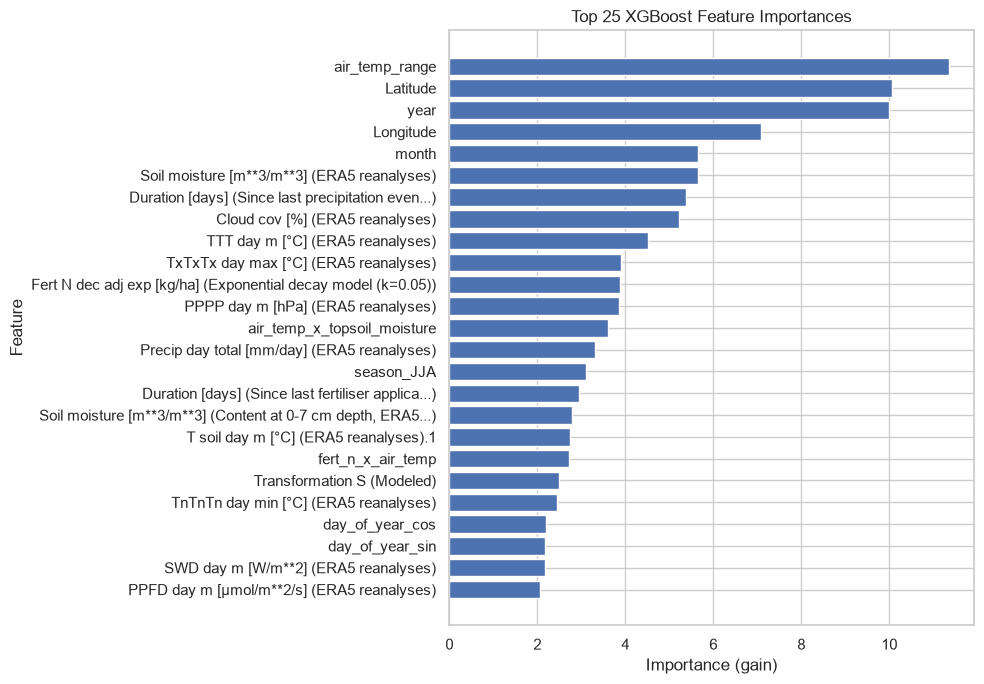

In [21]:
def plot_feature_importance(
    importance_df: pd.DataFrame,
    top_n: int = 25,
    verbose: bool = False,
) -> None:
    """
    Plot top feature importances as a horizontal bar chart.

    Parameters
    ----------
    importance_df : pd.DataFrame
        Feature importance table with columns 'feature' and 'importance'.
    top_n : int, default=25
        Number of top features to plot.
    verbose : bool, default=False
        If True, print plotting information.

    Returns
    -------
    None
    """
    required = {"feature", "importance"}
    if not required.issubset(importance_df.columns):
        raise ValueError(f"importance_df must contain columns: {required}")

    plot_df = importance_df.head(top_n).sort_values("importance", ascending=True)

    if verbose:
        print(f"Plotting top {len(plot_df)} features.")

    plt.figure(figsize=(10, max(5, top_n * 0.28)))
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.xlabel("Importance (gain)")
    plt.ylabel("Feature")
    plt.title(f"Top {len(plot_df)} XGBoost Feature Importances")
    plt.tight_layout()
    plt.show()


plot_feature_importance(importance_df, top_n=25, verbose=True)


## 14. Diagnostic Plots

The diagnostic plots visualize prediction quality and residual behavior on the holdout test set. They are used to inspect systematic deviations, heteroscedasticity, and the model behavior for high-emission observations.

Axis range: -12.7195 to 214.8084


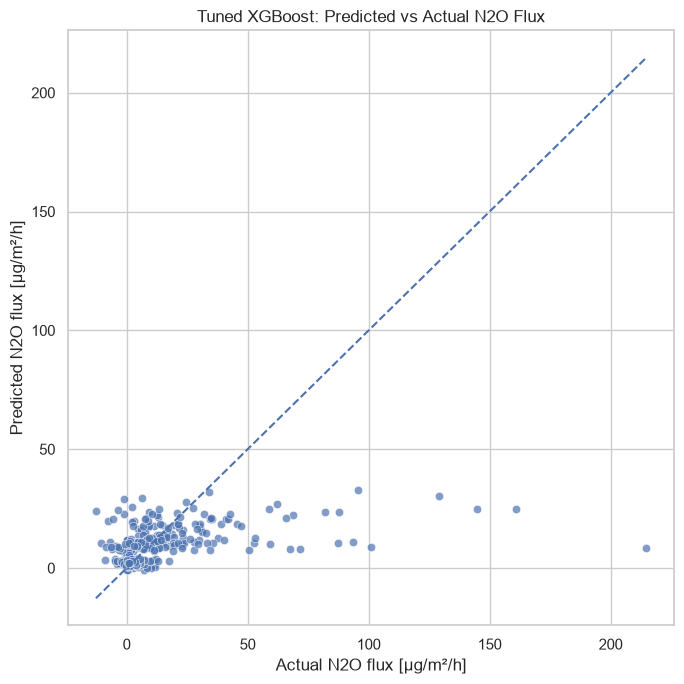

count    373.000000
mean       2.904330
std       21.078700
min      -36.589029
25%       -5.012597
50%       -1.094199
75%        2.858764
max      206.257585
dtype: float64


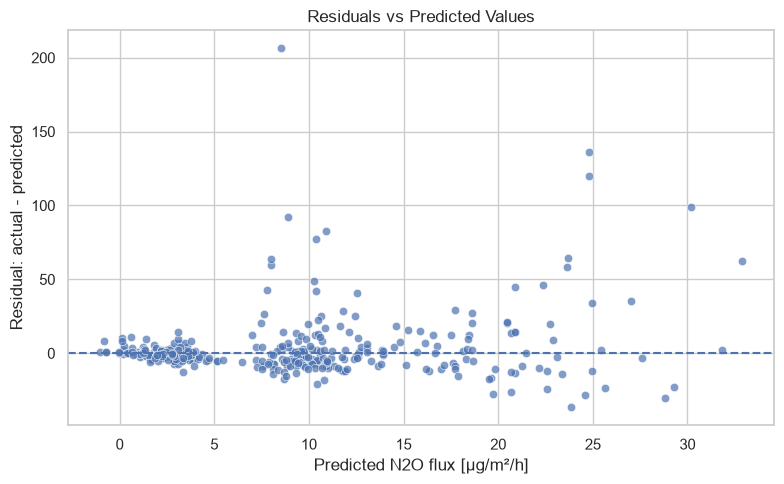

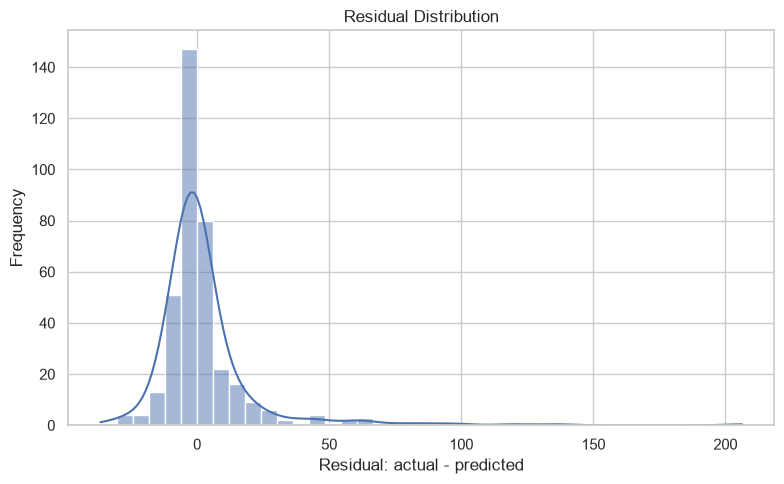

Land use
Forest       161
Grassland    122
Cropland      90
Name: count, dtype: int64


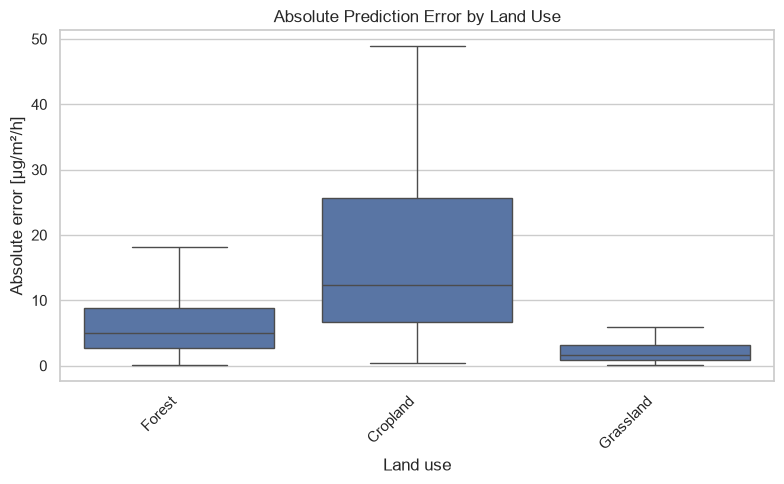

In [22]:
def plot_predicted_vs_actual(
    y_true: Sequence[float],
    y_pred: Sequence[float],
    title: str = "Predicted vs Actual",
    verbose: bool = False,
) -> None:
    """
    Plot predicted values against actual values.

    Parameters
    ----------
    y_true : Sequence[float]
        True target values.
    y_pred : Sequence[float]
        Predicted target values.
    title : str, default="Predicted vs Actual"
        Plot title.
    verbose : bool, default=False
        If True, print axis range information.

    Returns
    -------
    None
    """
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)

    axis_min = min(y_true_array.min(), y_pred_array.min())
    axis_max = max(y_true_array.max(), y_pred_array.max())

    if verbose:
        print(f"Axis range: {axis_min:.4f} to {axis_max:.4f}")

    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true_array, y=y_pred_array, alpha=0.7)
    plt.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--")
    plt.xlabel("Actual N2O flux [µg/m²/h]")
    plt.ylabel("Predicted N2O flux [µg/m²/h]")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_residuals(
    y_true: Sequence[float],
    y_pred: Sequence[float],
    verbose: bool = False,
) -> None:
    """
    Plot residual diagnostics.

    Parameters
    ----------
    y_true : Sequence[float]
        True target values.
    y_pred : Sequence[float]
        Predicted target values.
    verbose : bool, default=False
        If True, print residual summary statistics.

    Returns
    -------
    None
    """
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)
    residuals = y_true_array - y_pred_array

    if verbose:
        print(pd.Series(residuals).describe())

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred_array, y=residuals, alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted N2O flux [µg/m²/h]")
    plt.ylabel("Residual: actual - predicted")
    plt.title("Residuals vs Predicted Values")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, bins=40, kde=True)
    plt.xlabel("Residual: actual - predicted")
    plt.ylabel("Frequency")
    plt.title("Residual Distribution")
    plt.tight_layout()
    plt.show()


def plot_predictions_by_land_use(
    predictions_df: pd.DataFrame,
    land_use_column: str,
    verbose: bool = False,
) -> None:
    """
    Plot absolute error by land-use class.

    Parameters
    ----------
    predictions_df : pd.DataFrame
        Prediction DataFrame containing land use and absolute error.
    land_use_column : str
        Name of the land-use column.
    verbose : bool, default=False
        If True, print group counts.

    Returns
    -------
    None
    """
    required = {land_use_column, "absolute_error"}
    if not required.issubset(predictions_df.columns):
        raise ValueError(f"predictions_df must contain columns: {required}")

    if verbose:
        print(predictions_df[land_use_column].value_counts())

    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=predictions_df,
        x=land_use_column,
        y="absolute_error",
        showfliers=False,
    )
    plt.xlabel("Land use")
    plt.ylabel("Absolute error [µg/m²/h]")
    plt.title("Absolute Prediction Error by Land Use")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


plot_predicted_vs_actual(
    y_test,
    test_predictions,
    title="Tuned XGBoost: Predicted vs Actual N2O Flux",
    verbose=True,
)

plot_residuals(y_test, test_predictions, verbose=True)
plot_predictions_by_land_use(predictions_df, LAND_USE_COLUMN, verbose=True)


In [23]:
# Optional: inspect predictions for the largest absolute errors.
predictions_df.sort_values("absolute_error", ascending=False).head(20)


,Land use,Event,y_true,y_pred,residual,absolute_error
1590,Cropland,23ML-MACH,214.808427,8.550841,206.257585,206.257585
1521,Cropland,23ML-MACH,160.845870,24.788117,136.057753,136.057753
1523,Cropland,23ML-MACH,144.568865,24.788117,119.780748,119.780748
1500,Cropland,23ML-MACH,129.037121,30.192689,98.844432,98.844432
1557,Cropland,23ML-MACH,101.103017,8.882491,92.220527,92.220527
1051,Forest,25CA-SOR4D_DAF,93.700000,10.884772,82.815228,82.815228
1022,Forest,25CA-SOR4D_DAF,87.500000,10.364155,77.135845,77.135845
1507,Cropland,23ML-MACH,87.939558,23.662692,64.276866,64.276866
1565,Cropland,23ML-MACH,71.661532,8.015339,63.646192,63.646192
1496,Cropland,23ML-MACH,95.477820,32.876228,62.601592,62.601592


## 15. Save Model Artifacts

The fitted model and all relevant evaluation artifacts are exported for later reuse. The saved outputs include:

- the fitted preprocessing and XGBoost pipeline,
- the target shift required for inverse transformation,
- feature lists,
- evaluation metrics,
- holdout predictions,
- feature-importance values.

In [24]:
def save_model_artifacts(
    model: Pipeline,
    target_shift: float,
    metrics_table: pd.DataFrame,
    predictions_df: pd.DataFrame,
    importance_df: pd.DataFrame,
    numeric_features: Sequence[str],
    categorical_features: Sequence[str],
    output_dir: Path,
    verbose: bool = False,
) -> Dict[str, Path]:
    """
    Save model and model-building artifacts to disk.

    Parameters
    ----------
    model : Pipeline
        Fitted model pipeline.
    target_shift : float
        Shift used for target transformation.
    metrics_table : pd.DataFrame
        Evaluation metrics table.
    predictions_df : pd.DataFrame
        Holdout prediction table.
    importance_df : pd.DataFrame
        Feature importance table.
    numeric_features : Sequence[str]
        Numeric feature names.
    categorical_features : Sequence[str]
        Categorical feature names.
    output_dir : Path
        Directory where artifacts should be saved.
    verbose : bool, default=False
        If True, print saved file paths.

    Returns
    -------
    Dict[str, Path]
        Dictionary of artifact names and paths.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    artifact_bundle = {
        "model": model,
        "target_shift": target_shift,
        "target_transform": "shifted_log1p",
        "numeric_features": list(numeric_features),
        "categorical_features": list(categorical_features),
        "target_column": TARGET_COLUMN,
        "group_column": GROUP_COLUMN,
        "date_column": DATE_COLUMN,
        "land_use_column": LAND_USE_COLUMN,
    }

    model_path = output_dir / "xgboost_n2o_model.joblib"
    metrics_path = output_dir / "xgboost_n2o_metrics.csv"
    predictions_path = output_dir / "xgboost_n2o_holdout_predictions.csv"
    importance_path = output_dir / "xgboost_n2o_feature_importance.csv"

    joblib.dump(artifact_bundle, model_path)
    metrics_table.to_csv(metrics_path, index=True)
    predictions_df.to_csv(predictions_path, index=False)
    importance_df.to_csv(importance_path, index=False)

    paths = {
        "model": model_path,
        "metrics": metrics_path,
        "predictions": predictions_path,
        "feature_importance": importance_path,
    }

    if verbose:
        print("Saved artifacts:")
        for name, path in paths.items():
            print(f"- {name}: {path.resolve()}")

    return paths


ARTIFACT_DIR = project_root / "models" / "xgboost_n2o"

saved_paths = save_model_artifacts(
    model=best_xgb_log_model,
    target_shift=target_shift,
    metrics_table=metrics_table,
    predictions_df=predictions_df,
    importance_df=importance_df,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    output_dir=ARTIFACT_DIR,
    verbose=True,
)

saved_paths


Saved artifacts:
- model: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\models\xgboost_n2o\xgboost_n2o_model.joblib
- metrics: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\models\xgboost_n2o\xgboost_n2o_metrics.csv
- predictions: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\models\xgboost_n2o\xgboost_n2o_holdout_predictions.csv
- feature_importance: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\models\xgboost_n2o\xgboost_n2o_feature_importance.csv


{'model': WindowsPath('d:/Programming/general_projects/n2o_emission_africa/n2o-emissions-africa-ml/models/xgboost_n2o/xgboost_n2o_model.joblib'),
 'metrics': WindowsPath('d:/Programming/general_projects/n2o_emission_africa/n2o-emissions-africa-ml/models/xgboost_n2o/xgboost_n2o_metrics.csv'),
 'predictions': WindowsPath('d:/Programming/general_projects/n2o_emission_africa/n2o-emissions-africa-ml/models/xgboost_n2o/xgboost_n2o_holdout_predictions.csv'),
 'feature_importance': WindowsPath('d:/Programming/general_projects/n2o_emission_africa/n2o-emissions-africa-ml/models/xgboost_n2o/xgboost_n2o_feature_importance.csv')}

## 16. Optional Final Refit on All Data

The previous model represents the honest evaluation model, because it is trained only on the training split and evaluated on unseen events. After the holdout performance has been documented, a production-style model can optionally be refitted on all available observations using the selected hyperparameters.

This optional refit is not used to revise the holdout metrics. It only creates a final model artifact trained on the maximum available amount of data.

In [25]:
# Optional production-style refit on all available data.
# This model should not be used for holdout evaluation, because it has seen all observations.

REFIT_ON_ALL_DATA = False

if REFIT_ON_ALL_DATA:
    full_target_shift = calculate_log_shift(y, verbose=True)
    y_full_log = transform_target_log1p_shifted(y, shift=full_target_shift, verbose=True)

    final_model_all_data = clone(best_xgb_log_model)
    final_model_all_data.fit(X, y_full_log)

    final_artifact_dir = project_root / "models" / "xgboost_n2o_final_all_data"
    final_artifact_dir.mkdir(parents=True, exist_ok=True)

    final_bundle = {
        "model": final_model_all_data,
        "target_shift": full_target_shift,
        "target_transform": "shifted_log1p",
        "numeric_features": list(numeric_features),
        "categorical_features": list(categorical_features),
        "target_column": TARGET_COLUMN,
        "group_column": GROUP_COLUMN,
        "date_column": DATE_COLUMN,
        "land_use_column": LAND_USE_COLUMN,
    }

    final_model_path = final_artifact_dir / "xgboost_n2o_final_all_data.joblib"
    joblib.dump(final_bundle, final_model_path)

    print(f"Saved final all-data model to: {final_model_path.resolve()}")
else:
    print("Skipped final refit on all data. Set REFIT_ON_ALL_DATA = True to run it.")


Skipped final refit on all data. Set REFIT_ON_ALL_DATA = True to run it.


## 17. Summary and Next Steps

This section is reserved for the final interpretation after the notebook has been executed.

The modeling summary should document:

1. the baseline performance compared with the initial XGBoost model,
2. the tuned XGBoost performance on unseen events,
3. the effect of the shifted-log target transformation on MAE, RMSE, and residual behavior,
4. the most relevant predictors according to gain-based feature importance,
5. systematic error differences across land-use classes or events,
6. the model behavior for high-emission observations.

Potential next steps include:

- comparison with additional model families such as Random Forest, HistGradientBoosting, and ElasticNet,
- evaluation with leave-one-event-out cross-validation,
- testing a reduced feature set without model-derived variables such as `Transformation S` and `Transformation C`,
- SHAP-based interpretation for a more detailed explanation of model behavior,
- creation of a compact model card for the project README.

## Notes

This section contains manual observations, interpretation notes, and final remarks after executing the notebook.